# 02 — Model Selection & Cross-Asset Validation

**Part 1**: Grid search on SPY + threshold calibration + comparison table + feature importances  
**Part 2**: Cross-asset validation on SPY / DIA / QQQ

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.data_loader import load_data
from src.features import build_features, COLUMN_ORDER
from src.models import RFCModel, XGBModel

---
## Part 1 — Model Search & Comparison (SPY)
### Step 1 — Data Preparation

In [2]:

df_raw = load_data('SPY')
X_raw = build_features(df_raw)

df_spy = X_raw.copy()

ma50  = df_raw['Close'].rolling(50).mean()
ma200 = df_raw['Close'].rolling(200).mean()
gc    = (ma50 > ma200).astype(int)
gc_clean = gc.reset_index(drop=True)

transition = np.zeros(len(df_spy), dtype=int)
label = gc_clean.iloc[0]
for i in range(1, len(gc_clean)):
    if gc_clean.iloc[i] != label:
        label = gc_clean.iloc[i]
        start = max(0, i - 30)
        transition[start:i] = 1

df_spy['Transition'] = transition

df_spy = df_spy.dropna().reset_index(drop=True)


X = df_spy[COLUMN_ORDER]
y = df_spy['Transition']

split = int(len(df_spy) * 0.75)

X_train = X.iloc[:split]
X_test  = X.iloc[split:]
y_train = y.iloc[:split]
y_test  = y.iloc[split:]

print(f"Train size: {len(X_train)}  |  positives: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test size:  {len(X_test)}   |  positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
X_train.head(500)

Train size: 4563  |  positives: 528 (11.6%)
Test size:  1521   |  positives: 150 (9.9%)


,Return,Volatility,Cumulated_Return_5d,RSI14,Volume_ROC,ATR,VIX_spike,Distance_GC,MA_velocity,MA50_slope,Distance_normalized,MA_cross_momentum
0,0.004467,0.016713,0.016960,46.488146,-43.405512,2.234627,1.204567,0.008671,-0.559686,-0.011881,0.897115,56.401865
1,-0.006671,0.016545,0.035946,42.632105,-6.475955,2.254459,1.181164,0.007573,-0.525658,-0.012497,0.773336,78.072070
2,-0.023506,0.017220,0.015363,37.116459,100.083207,2.342288,1.290078,0.006090,-0.497000,-0.013276,0.612888,111.845169
3,0.002751,0.016896,-0.018843,42.134811,-6.681045,2.284917,1.375873,0.004669,-0.527377,-0.013361,0.463353,136.774924
4,0.018976,0.017493,-0.004467,48.775379,116.568323,2.317498,1.265942,0.003368,-0.554407,-0.013777,0.329132,185.006525
...,...,...,...,...,...,...,...,...,...,...,...,...
495,-0.024239,0.027371,0.108193,51.334584,17.412655,2.021276,1.000913,-0.133283,0.337901,-0.009746,-6.334754,3.166477
496,0.019873,0.026973,0.094754,59.368606,6.010676,2.010572,0.950624,-0.132059,0.454875,-0.009155,-6.282251,3.994451
497,0.004191,0.026969,0.053232,61.863579,-35.087501,2.023606,0.937234,-0.131280,0.475284,-0.008949,-6.256598,4.157029
498,0.017261,0.027023,0.065462,58.405743,-31.755362,1.959831,0.926530,-0.130296,0.476078,-0.007728,-6.220199,3.756755


In [3]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report

# most_frequent : always predict the majority class
dummy = DummyClassifier(strategy='most_frequent', random_state=42)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print("=== Baseline (Most Frequent) ===")
print(classification_report(y_test, y_pred_dummy, 
      target_names=['No Transition', 'Transition'], zero_division=0))

#stratified: predict randomly according to class distriution
dummy_strat = DummyClassifier(strategy='stratified', random_state=42)
dummy_strat.fit(X_train, y_train)
y_pred_strat = dummy_strat.predict(X_test)

print("=== Baseline (Stratified Random) ===")
print(classification_report(y_test, y_pred_strat,
      target_names=['No Transition', 'Transition'], zero_division=0))

=== Baseline (Most Frequent) ===
               precision    recall  f1-score   support

No Transition       0.90      1.00      0.95      1371
   Transition       0.00      0.00      0.00       150

     accuracy                           0.90      1521
    macro avg       0.45      0.50      0.47      1521
 weighted avg       0.81      0.90      0.85      1521

=== Baseline (Stratified Random) ===
               precision    recall  f1-score   support

No Transition       0.91      0.88      0.90      1371
   Transition       0.14      0.17      0.16       150

     accuracy                           0.81      1521
    macro avg       0.52      0.53      0.53      1521
 weighted avg       0.83      0.81      0.82      1521



In [4]:
rfc = RFCModel(
    n_estimators=500,
    max_depth=6,
    min_samples_split=6,
    min_samples_leaf=3
)
rfc.fit(X_train, y_train)

y_proba_rfc = rfc.predict_proba(X_test)
print("Threshold | Precision | Recall |  F1   | N_pred")
print("-" * 52)
for t in np.arange(0.3, 0.95, 0.05):
    pred = (y_proba_rfc >= t).astype(int)
    if pred.sum() > 0:
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f = f1_score(y_test, pred, zero_division=0)
        print(f"  {t:.2f}    |   {p:.3f}   |  {r:.3f} | {f:.3f} | {pred.sum()}")

Threshold | Precision | Recall |  F1   | N_pred
----------------------------------------------------
  0.30    |   0.340   |  0.933 | 0.498 | 412
  0.35    |   0.357   |  0.913 | 0.513 | 384
  0.40    |   0.392   |  0.900 | 0.547 | 344
  0.45    |   0.428   |  0.847 | 0.568 | 297
  0.50    |   0.466   |  0.813 | 0.592 | 262
  0.55    |   0.535   |  0.807 | 0.644 | 226
  0.60    |   0.631   |  0.787 | 0.700 | 187
  0.65    |   0.686   |  0.727 | 0.706 | 159
  0.70    |   0.758   |  0.627 | 0.686 | 124
  0.75    |   0.815   |  0.500 | 0.620 | 92
  0.80    |   0.811   |  0.200 | 0.321 | 37
  0.85    |   0.000   |  0.000 | 0.000 | 4


In [18]:
xgb = XGBModel(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.03,
    subsample=0.6,
    colsample_bytree=0.7,
    eval_metric='logloss',
    verbosity=0
)
xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)
print("Threshold | Precision | Recall |  F1   | N_pred")
print("-" * 52)
for t in np.arange(0.3, 0.95, 0.05):
    pred = (y_proba_xgb >= t).astype(int)
    if pred.sum() > 0:
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f = f1_score(y_test, pred, zero_division=0)
        print(f"  {t:.2f}    |   {p:.3f}   |  {r:.3f} | {f:.3f} | {pred.sum()}")

Threshold | Precision | Recall |  F1   | N_pred
----------------------------------------------------
  0.30    |   0.474   |  0.907 | 0.622 | 287
  0.35    |   0.481   |  0.907 | 0.628 | 283
  0.40    |   0.485   |  0.880 | 0.626 | 272
  0.45    |   0.496   |  0.853 | 0.627 | 258
  0.50    |   0.506   |  0.847 | 0.633 | 251
  0.55    |   0.510   |  0.833 | 0.633 | 245
  0.60    |   0.525   |  0.827 | 0.642 | 236
  0.65    |   0.552   |  0.820 | 0.660 | 223
  0.70    |   0.574   |  0.800 | 0.669 | 209
  0.75    |   0.613   |  0.793 | 0.692 | 194
  0.80    |   0.659   |  0.787 | 0.717 | 179
  0.85    |   0.706   |  0.767 | 0.735 | 163
  0.90    |   0.801   |  0.727 | 0.762 | 136


In [13]:
def compute_transition(df_raw):
    ma50  = df_raw['Close'].rolling(50).mean()
    ma200 = df_raw['Close'].rolling(200).mean()
    gc    = (ma50 > ma200).astype(int)
    transition = np.zeros(len(df_raw), dtype=int)
    label = gc.iloc[0]
    for i in range(1, len(gc)):
        if gc.iloc[i] != label:
            label = gc.iloc[i]
            start = max(0, i - 30)
            transition[start:i] = 1
    return pd.Series(transition, name='Transition')


def prepare_asset(ticker, split=0.75):
    df_raw = load_data(ticker)
    X_raw  = build_features(df_raw)
    df     = X_raw.copy()
    df['Transition'] = compute_transition(df_raw).values
    df     = df.dropna().reset_index(drop=True)
    split_idx = int(len(df) * split)
    X = df[COLUMN_ORDER]
    y = df['Transition']
    return X.iloc[split_idx:], y.iloc[split_idx:]


def validate_cross_assets(rfc_model, xgb_model, thresh_rfc, thresh_xgb, tickers):
    results = []
    for ticker in tickers:
        X_test, y_test = prepare_asset(ticker)
        print(f"\n{'='*50}")
        print(f"Asset: {ticker} | positives: {y_test.sum()} ({y_test.mean()*100:.1f}%)")

        for model, thresh, name in [
            (rfc_model, thresh_rfc, 'RFC'),
            (xgb_model, thresh_xgb, 'XGB')
        ]:
            proba = model.predict_proba(X_test)
            pred  = (proba >= thresh).astype(int)
            results.append({
                'Asset':     ticker,
                'Model':     name,
                'Precision': round(precision_score(y_test, pred, zero_division=0), 3),
                'Recall':    round(recall_score(y_test, pred, zero_division=0), 3),
                'F1':        round(f1_score(y_test, pred, zero_division=0), 3),
                'N_pred':    int(pred.sum())
            })

    df_results = pd.DataFrame(results)
    print("\n" + "="*60)
    print("CROSS-ASSET VALIDATION SUMMARY")
    print("="*60)
    print(df_results.to_string(index=False))
    print(f"\nMean F1 RFC: {df_results[df_results['Model']=='RFC']['F1'].mean():.3f}")
    print(f"Mean F1 XGB: {df_results[df_results['Model']=='XGB']['F1'].mean():.3f}")
    return df_results


results = validate_cross_assets(rfc, xgb, thresh_rfc=0.65, thresh_xgb=0.90, tickers=['SPY', 'DIA', 'QQQ'])


Asset: SPY | positives: 150 (9.9%)

Asset: DIA | positives: 157 (10.3%)

Asset: QQQ | positives: 132 (8.7%)

CROSS-ASSET VALIDATION SUMMARY
Asset Model  Precision  Recall    F1  N_pred
  SPY   RFC      0.686   0.727 0.706     159
  SPY   XGB      0.801   0.727 0.762     136
  DIA   RFC      0.522   0.682 0.591     205
  DIA   XGB      0.734   0.669 0.700     143
  QQQ   RFC      0.891   0.742 0.810     110
  QQQ   XGB      0.897   0.727 0.803     107

Mean F1 RFC: 0.702
Mean F1 XGB: 0.755


In [7]:
from sklearn.metrics import f1_score

def bootstrap_f1_ci(y_true, y_pred, B=1000, ci=95, random_state=42):
    
    rng = np.random.default_rng(random_state)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    n = len(y_true)

    f1_boot = np.zeros(B)
    for b in range(B):
        idx = rng.integers(0, n, size=n)          # resample with replacement
        f1_boot[b] = f1_score(y_true[idx], y_pred[idx], zero_division=0)

    alpha = (100 - ci) / 2
    ci_low  = np.percentile(f1_boot, alpha)
    ci_high = np.percentile(f1_boot, 100 - alpha)
    f1_obs  = f1_score(y_true, y_pred, zero_division=0)

    return f1_obs, ci_low, ci_high, f1_boot

def run_bootstrap_all_assets(rfc_model, xgb_model, thresh_rfc, thresh_xgb,
                              tickers, B=1000):

    rows = []
    for ticker in tickers:
        X_t, y_t = prepare_asset(ticker)
        for model, thresh, name in [
            (rfc_model,  thresh_rfc, 'RFC'),
            (xgb_model,  thresh_xgb, 'XGB'),
        ]:
            proba  = model.predict_proba(X_t)
            y_pred = (proba >= thresh).astype(int)

            f1_obs, ci_low, ci_high, _ = bootstrap_f1_ci(y_t, y_pred, B=B)

            rows.append({
                'Asset':   ticker,
                'Model':   name,
                'F1':      round(f1_obs,  3),
                'CI_low':  round(ci_low,  3),
                'CI_high': round(ci_high, 3),
                'CI_width': round(ci_high - ci_low, 3),
            })

    df_ci = pd.DataFrame(rows)
    print("\n" + "="*65)
    print("BOOTSTRAP CONFIDENCE INTERVALS (95%) — B=1000")
    print("="*65)
    print(df_ci.to_string(index=False))
    return df_ci


df_ci = run_bootstrap_all_assets(rfc, xgb, 0.65, 0.90,
                                 tickers=['SPY', 'DIA', 'QQQ'])


BOOTSTRAP CONFIDENCE INTERVALS (95%) — B=1000
Asset Model    F1  CI_low  CI_high  CI_width
  SPY   RFC 0.706   0.648    0.759     0.111
  SPY   XGB 0.762   0.707    0.810     0.103
  DIA   RFC 0.591   0.532    0.650     0.118
  DIA   XGB 0.700   0.641    0.753     0.113
  QQQ   RFC 0.810   0.758    0.858     0.100
  QQQ   XGB 0.803   0.747    0.854     0.107


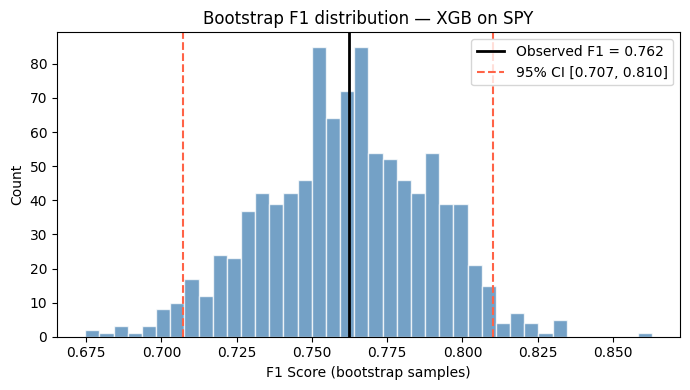

In [8]:
def plot_bootstrap_dist(y_true, y_pred, ticker, model_name, B=1000):
    f1_obs, ci_low, ci_high, f1_boot = bootstrap_f1_ci(y_true, y_pred, B=B)
    
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.hist(f1_boot, bins=40, color='steelblue', alpha=0.75, edgecolor='white')
    ax.axvline(f1_obs,  color='black',  lw=2,   label=f'Observed F1 = {f1_obs:.3f}')
    ax.axvline(ci_low,  color='tomato', lw=1.5, linestyle='--',
               label=f'95% CI [{ci_low:.3f}, {ci_high:.3f}]')
    ax.axvline(ci_high, color='tomato', lw=1.5, linestyle='--')
    ax.set_xlabel('F1 Score (bootstrap samples)')
    ax.set_ylabel('Count')
    ax.set_title(f'Bootstrap F1 distribution — {model_name} on {ticker}')
    ax.legend()
    plt.tight_layout()
    plt.savefig(f'bootstrap_{model_name}_{ticker}.png', dpi=150)
    plt.show()


# Example: XGB on SPY
X_spy_test, y_spy_test = prepare_asset('SPY')
y_pred_xgb_spy = (xgb.predict_proba(X_spy_test) >= 0.90).astype(int)
plot_bootstrap_dist(y_spy_test, y_pred_xgb_spy, 'SPY', 'XGB')


In [16]:
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
from scipy.stats import randint, uniform

# ── Scorer ──────────────────────────────────────────────────
f1_transition = make_scorer(f1_score, zero_division=0)

# ── Distributions ───────────────────────────────────────────
param_dist = {
    'n_estimators':     randint(200, 500),
    'max_depth':        randint(3, 8),
    'learning_rate':    uniform(0.01, 0.09),   # sample in [0.01, 0.10]
    'subsample':        uniform(0.5, 0.4),     # sample in [0.5, 0.9]
    'colsample_bytree': uniform(0.5, 0.4),     # sample in [0.5, 0.9]
}

# ── Search ──────────────────────────────────────────────────
tscv = TimeSeriesSplit(n_splits=5)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    scale_pos_weight=scale_pos_weight,
    eval_metric='logloss',
    verbosity=0,
    random_state=42
)

rs = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=100,              # 100 combinaisons aléatoires
    scoring=f1_transition,
    cv=tscv,
    n_jobs=-1,
    verbose=1,
    random_state=42,
    refit=True
)

rs.fit(X_train, y_train)

print("Best params :", rs.best_params_)
print("Best CV F1  :", round(rs.best_score_, 3))

Fitting 5 folds for each of 100 candidates, totalling 500 fits
Best params : {'colsample_bytree': np.float64(0.5325395122567599), 'learning_rate': np.float64(0.017635394267667272), 'max_depth': 5, 'n_estimators': 335, 'subsample': np.float64(0.6497083183024481)}
Best CV F1  : 0.647


In [14]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import f1_score, precision_score, recall_score
import numpy as np

tscv = TimeSeriesSplit(n_splits=5)

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

results = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_train)):
    X_f_train, X_f_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_f_train, y_f_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

    xgb_fold = XGBModel(
        n_estimators=300,
        max_depth=5,
        learning_rate=0.03,
        subsample=0.6,
        colsample_bytree=0.7,
        eval_metric='logloss',
        verbosity=0
    )
    xgb_fold.fit(X_f_train, y_f_train)

    proba = xgb_fold.predict_proba(X_f_val)
    pred  = (proba >= 0.90).astype(int)

    f1   = f1_score(y_f_val, pred, zero_division=0)
    prec = precision_score(y_f_val, pred, zero_division=0)
    rec  = recall_score(y_f_val, pred, zero_division=0)
    n_pos = y_f_val.sum()

    results.append({'Fold': fold+1, 'F1': f1, 'Precision': prec,
                    'Recall': rec, 'N_positive': n_pos})
    print(f"Fold {fold+1} | F1={f1:.3f} | P={prec:.3f} | R={rec:.3f} | "
          f"N_pos={n_pos} | Val size={len(val_idx)}")

df_cv = pd.DataFrame(results)
print(f"\nMean F1  : {df_cv['F1'].mean():.3f}")
print(f"Std  F1  : {df_cv['F1'].std():.3f}")
print(f"Min  F1  : {df_cv['F1'].min():.3f}")
print(f"Max  F1  : {df_cv['F1'].max():.3f}")

Fold 1 | F1=0.145 | P=1.000 | R=0.078 | N_pos=115 | Val size=760
Fold 2 | F1=0.463 | P=0.629 | R=0.367 | N_pos=60 | Val size=760
Fold 3 | F1=0.561 | P=0.941 | R=0.400 | N_pos=120 | Val size=760
Fold 4 | F1=0.427 | P=0.941 | R=0.276 | N_pos=58 | Val size=760
Fold 5 | F1=0.587 | P=0.949 | R=0.425 | N_pos=87 | Val size=760

Mean F1  : 0.437
Std  F1  : 0.176
Min  F1  : 0.145
Max  F1  : 0.587
